# New section

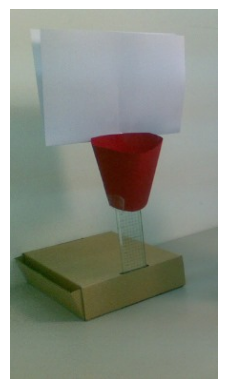

In [8]:
import matplotlib.pyplot as plt
import cv2

# Read image FIRST
img = cv2.imread('Basket.jpeg')

# Convert BGR → RGB (correct direction!)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()

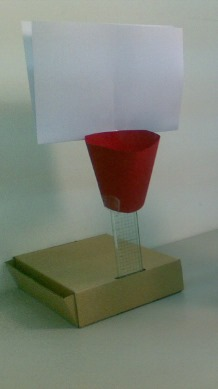

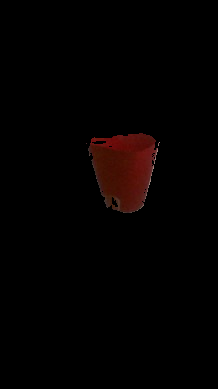

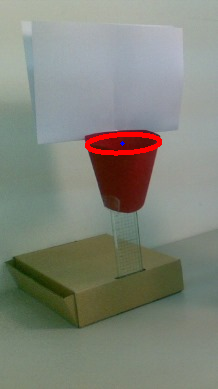

In [7]:
import numpy as np
import cv2
redbasket=cv2.imread('Basket.jpeg')
from google.colab.patches import cv2_imshow
cv2_imshow(redbasket)

# locate basket
hsv = cv2.cvtColor(redbasket, cv2.COLOR_BGR2HSV)

lower_red = np.array([0, 50, 30])
upper_red = np.array([10, 255, 255])

mask = cv2.inRange(hsv, lower_red, upper_red)

res = cv2.bitwise_and(redbasket,redbasket, mask = mask)
cv2_imshow(res)

# max contour
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnt = max(contours, key=cv2.contourArea)

# bounding box of bucket
x, y, w, h = cv2.boundingRect(cnt)

# take only top part of bucket (rim area)
top_mask = mask[y:y + int(0.2*h), x:x+w]

# find contours in this top region
contours_top, _ = cv2.findContours(top_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# pick largest contour in top region(i.e. rim boundary)
cnt_top = max(contours_top, key=cv2.contourArea)

# shift contour back to original position
cnt_top = cnt_top + [x, y]

# fit ellipse on rim
ellipse = cv2.fitEllipse(cnt_top)

# draw result
output = redbasket.copy()
cv2.ellipse(output, ellipse, (0,0,255), 3)

(cx, cy), _, _ = ellipse
cv2.circle(output, (int(cx), int(cy)), 2, (255,0,0), -1)

cv2_imshow(output)